Maximum: 0.0
Minimum: -80.0


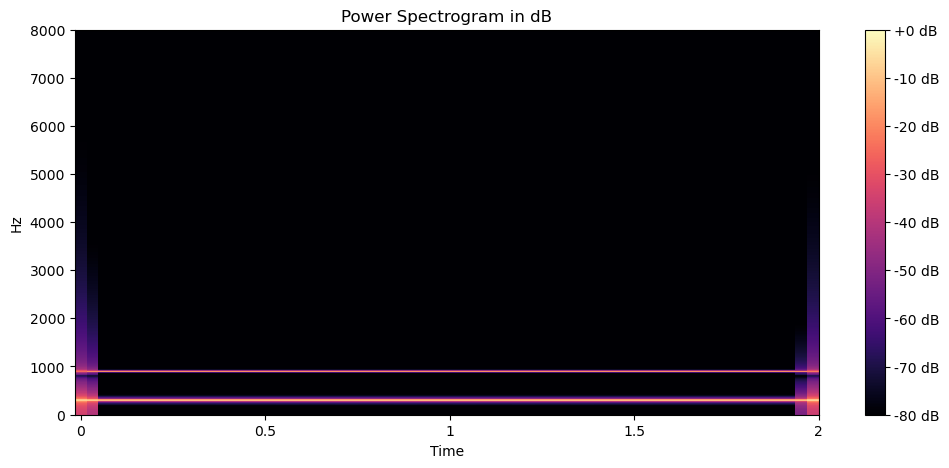

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

sample_rate = 16000
duration = 2.0

N = int(sample_rate * duration)
time = np.arange(N) / sample_rate

signal = (
    np.sin(2 * np.pi * 300 * time)
    +
    0.1 * np.sin(2 * np.pi * 900 * time)
)

stft = librosa.stft(
    signal,
    n_fft=2048,
    hop_length=512
)

power = np.abs(stft) ** 2

power_db = librosa.power_to_db(
    power,
    ref=np.max,
    top_db=80
)

print("Maximum:", power_db.max())
print("Minimum:", power_db.min())

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    power_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram in dB")
plt.show()

In [2]:
"""
You should see roughly:
Maximum: 0 dB
Minimum: -80 dB
because of:
top_db=80
"""

'\nYou should see roughly:\nMaximum: 0 dB\nMinimum: -80 dB\nbecause of:\ntop_db=80\n'

In [3]:
"""
Decibels are not a new signal representation by themselves.
They are just a logarithmic way of expressing a ratio relative to some reference:

dB = logarithmic relative strength
And dynamic range tells you: how far apart the strongest and weakest useful levels are

"""

'\nDecibels are not a new signal representation by themselves.\nThey are just a logarithmic way of expressing a ratio relative to some reference:\n\\[\n\x08oxed{\n\text{dB}\n=\n\text{logarithmic relative strength}And dynamic range tells you: how far apart the strongest and weakest useful levels are\n\n'

In [ ]:
"""
top_db
Librosa also commonly uses a parameter like:
power_db = librosa.power_to_db(
    power_spectrogram,
    ref=np.max,
    top_db=80
)
This means:
Don't keep values more than 80 dB below the maximum.

So values below: -80dB are clipped to:-80
"""